In [1]:
import sys
from pathlib import Path
import time

import numpy as np
import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from algorithms.graph import is_independent
from algorithms.greedy import greedy_mis
from algorithms.genetic_algorithm import genetic_algorithm
from algorithms.tabu_search import tabu_search
from algorithms.cplex_mis import cplex_mis

In [2]:
large_dir = project_root / "data" / "large"

large_instances = sorted(large_dir.glob("*.npy"))

print(f"Broj large instanci: {len(large_instances)}")

for path in large_instances:
    graph = np.load(path)
    print(path.name, "n =", len(graph))

Broj large instanci: 30
large_n100_01.npy n = 100
large_n100_02.npy n = 100
large_n100_03.npy n = 100
large_n100_04.npy n = 100
large_n100_05.npy n = 100
large_n100_06.npy n = 100
large_n100_07.npy n = 100
large_n100_08.npy n = 100
large_n100_09.npy n = 100
large_n100_10.npy n = 100
large_n150_01.npy n = 150
large_n150_02.npy n = 150
large_n150_03.npy n = 150
large_n150_04.npy n = 150
large_n150_05.npy n = 150
large_n150_06.npy n = 150
large_n150_07.npy n = 150
large_n150_08.npy n = 150
large_n150_09.npy n = 150
large_n150_10.npy n = 150
large_n75_01.npy n = 75
large_n75_02.npy n = 75
large_n75_03.npy n = 75
large_n75_04.npy n = 75
large_n75_05.npy n = 75
large_n75_06.npy n = 75
large_n75_07.npy n = 75
large_n75_08.npy n = 75
large_n75_09.npy n = 75
large_n75_10.npy n = 75


In [3]:
import cplex

print(cplex.__version__)

22.2.0.0


In [4]:
cplex_results = []

for path in large_instances:
    graph = np.load(path)

    print(f"Obrada: {path.name} (n = {len(graph)})")

    start = time.perf_counter()

    try:
        solution = cplex_mis(graph)
        elapsed = time.perf_counter() - start

        cplex_results.append({
            "Instance": path.stem,
            "n": len(graph),
            "Algorithm": "ILP (CPLEX)",
            "Solution Size": len(solution),
            "Time (s)": elapsed,
            "Valid": is_independent(graph, solution),
            "Status": "OK"
        })

        print(f"  OK: {len(solution)}")

    except Exception as e:
        elapsed = time.perf_counter() - start

        cplex_results.append({
            "Instance": path.stem,
            "n": len(graph),
            "Algorithm": "ILP (CPLEX)",
            "Solution Size": None,
            "Time (s)": elapsed,
            "Valid": None,
            "Status": "Problem size exceeded"
        })

        print("  CPLEX nije mogao da reši instancu.")

cplex_results = pd.DataFrame(cplex_results)

cplex_results

Obrada: large_n100_01.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_02.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_03.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_04.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_05.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_06.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_07.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_08.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_09.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n100_10.npy (n = 100)
  CPLEX nije mogao da reši instancu.
Obrada: large_n150_01.npy (n = 150)
  CPLEX nije mogao da reši instancu.
Obrada: large_n150_02.npy (n = 150)
  CPLEX nije mogao da reši instancu.
Obrada: large_n150_03.npy (n = 150)
  CPLEX nije mogao da reši instancu.
Obrada: large_n150_04.npy (n = 150)
  CPLEX nije mo

,Instance,n,Algorithm,Solution Size,Time (s),Valid,Status
0,large_n100_01,100,ILP (CPLEX),NaN,0.007302,None,Problem size exceeded
1,large_n100_02,100,ILP (CPLEX),NaN,0.005128,None,Problem size exceeded
2,large_n100_03,100,ILP (CPLEX),NaN,0.005396,None,Problem size exceeded
3,large_n100_04,100,ILP (CPLEX),NaN,0.006550,None,Problem size exceeded
4,large_n100_05,100,ILP (CPLEX),NaN,0.005961,None,Problem size exceeded
5,large_n100_06,100,ILP (CPLEX),NaN,0.005790,None,Problem size exceeded
6,large_n100_07,100,ILP (CPLEX),NaN,0.005353,None,Problem size exceeded
7,large_n100_08,100,ILP (CPLEX),NaN,0.005506,None,Problem size exceeded
8,large_n100_09,100,ILP (CPLEX),NaN,0.007080,None,Problem size exceeded
9,large_n100_10,100,ILP (CPLEX),NaN,0.005034,None,Problem size exceeded


In [5]:
cplex_successful = cplex_results[
    cplex_results["Status"] == "OK"
].copy()

cplex_successful

,Instance,n,Algorithm,Solution Size,Time (s),Valid,Status
20,large_n75_01,75,ILP (CPLEX),14.0,0.146588,True,OK
21,large_n75_02,75,ILP (CPLEX),12.0,0.119962,True,OK
22,large_n75_03,75,ILP (CPLEX),13.0,0.113763,True,OK
23,large_n75_04,75,ILP (CPLEX),13.0,0.117556,True,OK
24,large_n75_05,75,ILP (CPLEX),13.0,0.123224,True,OK
25,large_n75_06,75,ILP (CPLEX),13.0,0.119363,True,OK
26,large_n75_07,75,ILP (CPLEX),14.0,0.111502,True,OK
27,large_n75_08,75,ILP (CPLEX),14.0,0.116751,True,OK
28,large_n75_09,75,ILP (CPLEX),13.0,0.119548,True,OK
29,large_n75_10,75,ILP (CPLEX),14.0,0.114796,True,OK


In [6]:
print("Uspešno rešeno:", len(cplex_successful))
print("Nije moguće rešiti:", len(cplex_results) - len(cplex_successful))

Uspešno rešeno: 10
Nije moguće rešiti: 20


#### Greedy algoritam nad lagre instancama

In [7]:
greedy_results = []

for path in large_instances:
    graph = np.load(path)

    start = time.perf_counter()

    solution = greedy_mis(graph)

    elapsed = time.perf_counter() - start

    greedy_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Greedy",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

greedy_results = pd.DataFrame(greedy_results)

greedy_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,large_n100_01,100,Greedy,15,0.007580,True
1,large_n100_02,100,Greedy,13,0.005718,True
2,large_n100_03,100,Greedy,13,0.007075,True
3,large_n100_04,100,Greedy,13,0.005886,True
4,large_n100_05,100,Greedy,14,0.005864,True
5,large_n100_06,100,Greedy,12,0.006341,True
6,large_n100_07,100,Greedy,13,0.005255,True
7,large_n100_08,100,Greedy,13,0.006253,True
8,large_n100_09,100,Greedy,13,0.007250,True
9,large_n100_10,100,Greedy,12,0.005905,True


In [8]:
print("Broj instanci:", len(greedy_results))
print("Nevalidna rešenja:", (~greedy_results["Valid"]).sum())
print("Najduže vreme:", greedy_results["Time (s)"].max())

Broj instanci: 30
Nevalidna rešenja: 0
Najduže vreme: 0.013891651000449201


#### Genetic algoritam za large instance

In [9]:
ga_results = []

for path in large_instances:
    graph = np.load(path)

    start = time.perf_counter()

    solution = genetic_algorithm(
        graph,
        population_size=50,
        max_evaluations=20000,
        crossover_rate=0.6
    )

    elapsed = time.perf_counter() - start

    ga_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Genetic Algorithm",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

ga_results = pd.DataFrame(ga_results)

ga_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,large_n100_01,100,Genetic Algorithm,5,1.724500,True
1,large_n100_02,100,Genetic Algorithm,8,1.621603,True
2,large_n100_03,100,Genetic Algorithm,8,1.627137,True
3,large_n100_04,100,Genetic Algorithm,5,1.719752,True
4,large_n100_05,100,Genetic Algorithm,8,1.688030,True
5,large_n100_06,100,Genetic Algorithm,6,1.712286,True
6,large_n100_07,100,Genetic Algorithm,7,1.661159,True
7,large_n100_08,100,Genetic Algorithm,4,1.643021,True
8,large_n100_09,100,Genetic Algorithm,7,1.605429,True
9,large_n100_10,100,Genetic Algorithm,8,1.666296,True


In [11]:
print("Broj instanci:", len(ga_results))
print("Nevalidna rešenja:", (~ga_results["Valid"]).sum())
print("Najduže vreme:", ga_results["Time (s)"].max())
print("Rešenja veličine 0:", (ga_results["Solution Size"] == 0).sum())

Broj instanci: 30
Nevalidna rešenja: 0
Najduže vreme: 3.0696437239967054
Rešenja veličine 0: 8


#### Tabu algoritam nad large instancama

In [12]:
tabu_results = []

for path in large_instances:
    graph = np.load(path)

    start = time.perf_counter()

    solution = tabu_search(
        graph,
        iterations=100,
        tabu_tenure=5
    )

    elapsed = time.perf_counter() - start

    tabu_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Tabu Search",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

tabu_results = pd.DataFrame(tabu_results)

tabu_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,large_n100_01,100,Tabu Search,14,0.034348,True
1,large_n100_02,100,Tabu Search,12,0.029562,True
2,large_n100_03,100,Tabu Search,14,0.032580,True
3,large_n100_04,100,Tabu Search,13,0.031535,True
4,large_n100_05,100,Tabu Search,11,0.027588,True
5,large_n100_06,100,Tabu Search,12,0.030688,True
6,large_n100_07,100,Tabu Search,12,0.029945,True
7,large_n100_08,100,Tabu Search,14,0.031918,True
8,large_n100_09,100,Tabu Search,14,0.032297,True
9,large_n100_10,100,Tabu Search,12,0.029298,True


In [15]:
print("Broj instanci:", len(tabu_results))
print("Nevalidna rešenja:", (~tabu_results["Valid"]).sum())
print("Najduže vreme:", tabu_results["Time (s)"].max())

Broj instanci: 30
Nevalidna rešenja: 0
Najduže vreme: 0.05715286600025138


#### Poređenje rezultata

In [22]:
# Spajamo rezultate svih algoritama

all_results = pd.concat([
    cplex_results,
    greedy_results,
    ga_results,
    tabu_results
], ignore_index=True)

# Optimalne vrednosti postoje samo za instance koje je CPLEX uspešno rešio
optimal = (
    cplex_results[cplex_results["Status"] == "OK"]
    [["Instance", "Solution Size"]]
    .rename(columns={"Solution Size": "Optimal"})
)

# Dodajemo optimalne vrednosti rezultatima
all_results = all_results.merge(
    optimal,
    on="Instance",
    how="left"
)

# Provera da li je pronađeno optimalno rešenje
all_results["Optimal Found"] = (
    all_results["Solution Size"] == all_results["Optimal"]
)

all_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid,Status,Optimal,Optimal Found
0,large_n100_01,100,ILP (CPLEX),NaN,0.007302,None,Problem size exceeded,NaN,False
1,large_n100_02,100,ILP (CPLEX),NaN,0.005128,None,Problem size exceeded,NaN,False
2,large_n100_03,100,ILP (CPLEX),NaN,0.005396,None,Problem size exceeded,NaN,False
3,large_n100_04,100,ILP (CPLEX),NaN,0.006550,None,Problem size exceeded,NaN,False
4,large_n100_05,100,ILP (CPLEX),NaN,0.005961,None,Problem size exceeded,NaN,False
...,...,...,...,...,...,...,...,...,...
115,large_n75_06,75,Tabu Search,11.0,0.022970,True,NaN,13.0,False
116,large_n75_07,75,Tabu Search,13.0,0.023624,True,NaN,14.0,False
117,large_n75_08,75,Tabu Search,12.0,0.021730,True,NaN,14.0,False
118,large_n75_09,75,Tabu Search,10.0,0.019829,True,NaN,13.0,False


In [27]:
all_results.to_csv(
    project_root / "results" / "large_results.csv",
    index=False
)

print("Rezultati su sačuvani.")

Rezultati su sačuvani.


In [25]:
summary = (
    all_results
    .groupby("Algorithm")
    .agg(
        **{
            "Vrednost funkcije cilja": ("Solution Size", "mean"),
            "Vreme izvršavanja": ("Time (s)", "mean")
        }
    )
    .reset_index()
)

summary

,Algorithm,Vrednost funkcije cilja,Vreme izvršavanja
0,Genetic Algorithm,5.100000,1.921575
1,Greedy,13.366667,0.007394
2,ILP (CPLEX),13.300000,0.046198
3,Tabu Search,12.966667,0.035467


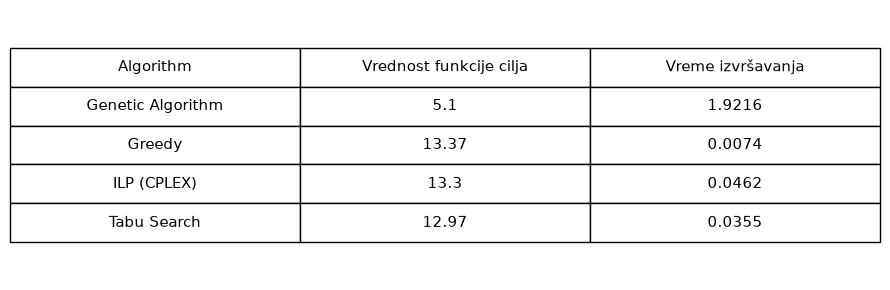

Tabela je sačuvana u: /home/hpdeb/Documents/RI/maximum-independent-set/results/large_summary.png


In [26]:
import matplotlib.pyplot as plt

table_data = summary.copy()

table_data["Vrednost funkcije cilja"] = (
    table_data["Vrednost funkcije cilja"].round(2)
)

table_data["Vreme izvršavanja"] = (
    table_data["Vreme izvršavanja"].round(4)
)

fig, ax = plt.subplots(figsize=(9, 3))

ax.axis("off")

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

plt.tight_layout()

output_path = project_root / "results" / "large_summary.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Tabela je sačuvana u: {output_path}")